Import Libraries

In [2]:
pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 1.3 MB/s eta 0:00:07
   --- ------------------------------------ 0.8/9.5 MB 1.6 MB/s eta 0:00:06
   ----- ---------------------------------- 1.3/9.5 MB 1.7 MB/s eta 0:00:05
   ------ --------------------------------- 1.6/9.5 MB 1.8 MB/s eta 0:00:05
   -------- ------------------------------- 2.1/9.5 MB 1.8 MB/s eta 0:00:05
   ----------- ---------------------------- 2.6/9.5 MB 1.8 MB/s eta 0:00:04
   ------------- -------------------------- 3.1/9.5 MB 2.0 MB/s eta 0:00:04
   -------------- ------------------------- 3.4/9.5 MB 1.9 MB/s eta 0:00:04
   ---------------- ----------------------- 3.9/9.5 MB 1.9 MB/s eta 0:00:03
   ------------------ --------------------- 4.5/

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Load Dataset

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("Cleaned_Dataset.xlsx")

Dataset overview

In [5]:
df.shape

(1200, 14)

In [6]:
df.columns.tolist()

['OrderID',
 'Date',
 'CustomerID',
 'Product',
 'Quantity',
 'UnitPrice',
 'ShippingAddress',
 'PaymentMethod',
 'OrderStatus',
 'TrackingNumber',
 'ItemsInCart',
 'CouponCode',
 'ReferralSource',
 'TotalPrice']

In [7]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


Descriptive Statistics

In [8]:
df[['Quantity','UnitPrice','ItemsInCart','TotalPrice']].describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


In [9]:
print("Mean:", df['TotalPrice'].mean())
print("Median:", df['TotalPrice'].median())
print("Count:", df['TotalPrice'].count())

Mean: 1053.9683
Median: 823.615
Count: 1200


Product Analysis

In [10]:
df['Product'].value_counts()

Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

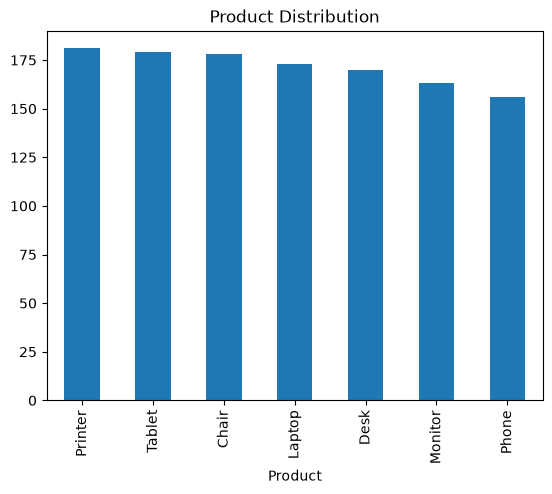

In [11]:
df['Product'].value_counts().plot(kind='bar')
plt.title("Product Distribution")
plt.show()

Payment Method Analysis

In [12]:
df['PaymentMethod'].value_counts()

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

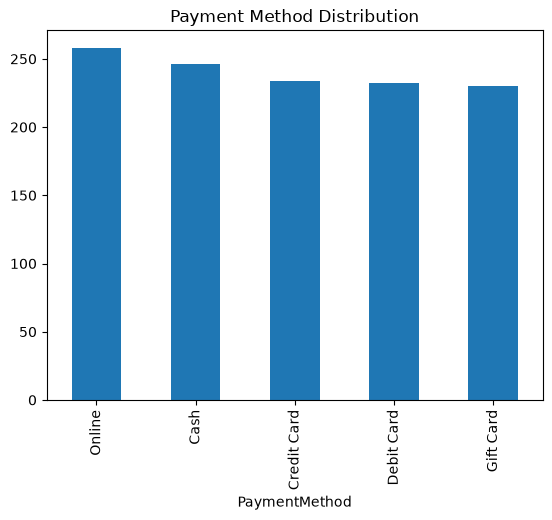

In [13]:
df['PaymentMethod'].value_counts().plot(kind='bar')
plt.title("Payment Method Distribution")
plt.show()

Order Status Analysis

In [14]:
df['OrderStatus'].value_counts()

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

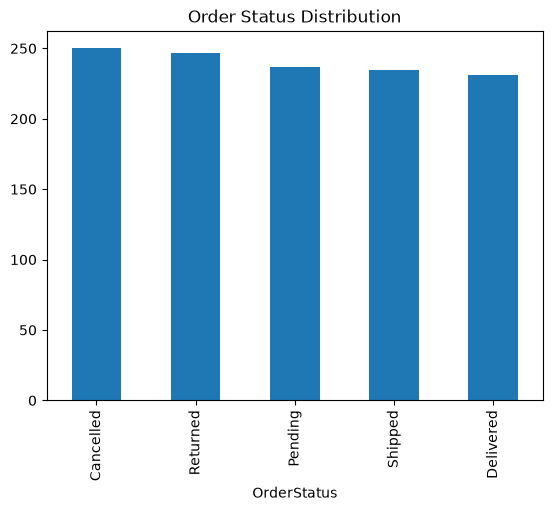

In [15]:
df['OrderStatus'].value_counts().plot(kind='bar')
plt.title("Order Status Distribution")
plt.show()

Referral Source Analysis

In [23]:
df['ReferralSource'].value_counts()

ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64

Monthly Sales Trend

In [16]:
df['Month'] = df['Date'].dt.to_period('M')

In [17]:
monthly_sales = df.groupby('Month')['TotalPrice'].sum()
monthly_sales

Month
2023-01    56685.75
2023-02    40117.66
2023-03    48609.37
2023-04    27751.71
2023-05    63836.84
2023-06    49500.19
2023-07    42820.66
2023-08    54352.14
2023-09    29526.67
2023-10    52607.85
2023-11    43079.67
2023-12    43754.73
2024-01    38528.08
2024-02    36909.57
2024-03    36030.90
2024-04    49613.14
2024-05    27909.11
2024-06    68068.54
2024-07    42963.98
2024-08    31991.07
2024-09    39794.98
2024-10    37226.97
2024-11    32413.76
2024-12    38785.77
2025-01    29099.40
2025-02    35317.55
2025-03    39200.66
2025-04    31821.20
2025-05    43396.64
2025-06    53047.40
Freq: M, Name: TotalPrice, dtype: float64

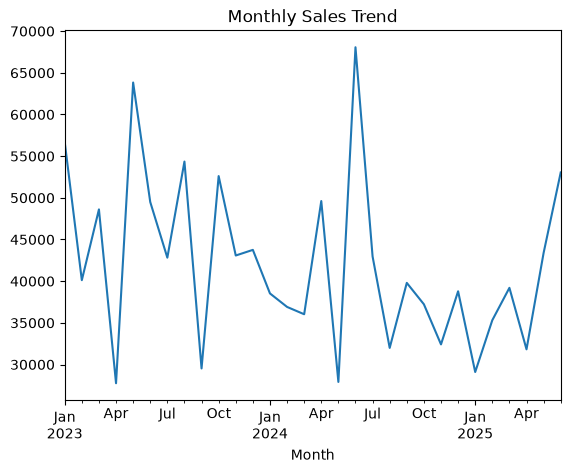

In [18]:
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.show()

Outlier Detection

In [19]:
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)

IQR = Q3 - Q1

outliers = df[
    (df['TotalPrice'] < Q1 - 1.5 * IQR)
    |
    (df['TotalPrice'] > Q3 + 1.5 * IQR)
]

print("Outliers:", len(outliers))

Outliers: 8


In [25]:
Q1 = df['Quantity'].quantile(0.25)
Q3 = df['Quantity'].quantile(0.75)

IQR = Q3 - Q1

outliers_qty = df[
    (df['Quantity'] < Q1 - 1.5*IQR)
    |
    (df['Quantity'] > Q3 + 1.5*IQR)
]

print(len(outliers_qty))

0


In [26]:
Q1 = df['UnitPrice'].quantile(0.25)
Q3 = df['UnitPrice'].quantile(0.75)

In [27]:
Q1 = df['ItemsInCart'].quantile(0.25)
Q3 = df['ItemsInCart'].quantile(0.75)

# Key Observations

- The dataset contains 1200 customer orders.
- The average order value is ₹1053.97.
- Customers purchase approximately 3 units per order.
- Printer is the most purchased product.
- Phone is the least purchased product.
- Online payment is the most preferred payment method.
- Instagram is the leading customer acquisition source.
- June 2024 recorded the highest sales revenue.
- 8 outlier transactions were identified.

# Conclusion

Exploratory Data Analysis was performed on the e-commerce dataset.

The analysis identified product demand patterns, customer payment preferences, referral performance, monthly sales trends, and unusual transactions. Printer emerged as the most purchased product, Online was the preferred payment method, and Instagram generated the highest customer traffic.

A total of 8 outlier transactions were detected. Overall, the dataset provides valuable business insights and is ready for further reporting and visualization.